# SupplyPrescript — Corrected Machine Learning Pipeline

This notebook is the cleaned version of the supplied SupplyPrescript ML notebook.

**Evaluation rule used throughout:**

`TRAIN → model fitting / grouped CV`  
`VALIDATION → feature/model/threshold decisions`  
`TEST → final evaluation once, after the pipeline is locked`

The notebook also prevents line-items from the same reconstructed order from crossing data splits.
> **Execution requirement:** after placing the CSV beside this notebook (or uploading it in Colab), use **Runtime → Restart session and run all**. Do not report model metrics from a partially executed notebook.


In [1]:
# ============================================================
# 0. OPTIONAL DEPENDENCY INSTALLATION
# ============================================================
# Installs only packages that are missing in the current runtime.

import importlib.util
import subprocess
import sys

required_packages = [
    "xgboost",
    "lightgbm",
    "catboost",
    "shap",
]

for package in required_packages:
    if importlib.util.find_spec(package) is None:
        print(f"Installing {package}...")
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", package
        ])

print("Dependency check complete.")

Installing catboost...
Dependency check complete.


In [2]:
# ============================================================
# 1. IMPORTS AND GLOBAL SETTINGS
# ============================================================

from pathlib import Path
import os
import json
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    GroupShuffleSplit,
    RandomizedSearchCV,
    StratifiedGroupKFold,
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc,
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TARGET = "Late_delivery_risk"
UNKNOWN_CATEGORY = "__UNKNOWN__"

# IMPORTANT BUSINESS CONFIGURATION
# Set this to True ONLY if the Order Status available in this dataset is
# genuinely known at the exact moment the production prediction is made.
ORDER_STATUS_AVAILABLE_AT_PREDICTION = False

# Orders in these terminal/business-exception states are NOT part of the
# delivery-risk modeling population because they never represent a
# completed shipment outcome. They are filtered BEFORE splitting.
NON_SHIPMENT_STATUSES = ("CANCELED", "SUSPECTED_FRAUD")

# Hyperparameter search can take several minutes on Colab.
RUN_XGB_TUNING = True
N_TUNING_ITER = 15

print("Setup complete.")
print("ORDER_STATUS_AVAILABLE_AT_PREDICTION =", ORDER_STATUS_AVAILABLE_AT_PREDICTION)

Setup complete.
ORDER_STATUS_AVAILABLE_AT_PREDICTION = False


## 2. Load the processed feature CSV

If `supply_prescript_features[2].csv` is already present in the runtime, the notebook uses it. Otherwise, in Google Colab it opens the upload dialog.

In [3]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

DEFAULT_DATA_NAME = "supply_prescript_features[2].csv"

if Path(DEFAULT_DATA_NAME).exists():
    DATA_PATH = DEFAULT_DATA_NAME
elif Path("/mnt/data/supply_prescript_features[2].csv").exists():
    # Useful outside Colab / in the ChatGPT working runtime.
    DATA_PATH = "/mnt/data/supply_prescript_features[2].csv"
else:
    try:
        from google.colab import files
        uploaded = files.upload()
        if not uploaded:
            raise RuntimeError("No CSV was uploaded.")
        DATA_PATH = next(iter(uploaded.keys()))
    except ImportError as exc:
        raise FileNotFoundError(
            f"Could not find {DEFAULT_DATA_NAME}. Put the CSV beside the notebook "
            "or set DATA_PATH manually."
        ) from exc

print("Loading:", DATA_PATH)
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Saving supply_prescript_features[1].csv to supply_prescript_features[1].csv
Loading: supply_prescript_features[1].csv
Dataset shape: (180519, 36)


,Type,Days for shipment (scheduled),Benefit per order,Sales per customer,Category Name,Customer City,Customer Country,Customer Segment,Customer State,Customer Zipcode,...,Order Status,Product Category Id,Product Name,Product Price,Shipping Mode,Order_Year,Order_Month,Order_DayOfWeek,Order_Day,Late_delivery_risk
0,DEBIT,4,91.250000,314.640015,Sporting Goods,Caguas,Puerto Rico,Consumer,PR,725.0,...,COMPLETE,73,Smart watch,327.75,Standard Class,2018,1,2,31,0
1,TRANSFER,4,-249.089996,311.359985,Sporting Goods,Caguas,Puerto Rico,Consumer,PR,725.0,...,PENDING,73,Smart watch,327.75,Standard Class,2018,1,5,13,1
2,CASH,4,-247.779999,309.720001,Sporting Goods,San Jose,EE. UU.,Consumer,CA,95125.0,...,CLOSED,73,Smart watch,327.75,Standard Class,2018,1,5,13,0
3,DEBIT,4,22.860001,304.809998,Sporting Goods,Los Angeles,EE. UU.,Home Office,CA,90027.0,...,COMPLETE,73,Smart watch,327.75,Standard Class,2018,1,5,13,0
4,PAYMENT,4,134.210007,298.250000,Sporting Goods,Caguas,Puerto Rico,Corporate,PR,725.0,...,PENDING_PAYMENT,73,Smart watch,327.75,Standard Class,2018,1,5,13,0


In [4]:
# ============================================================
# 3. BASIC DATA QUALITY CHECKS
# ============================================================

print("Number of columns:", len(df.columns))
print("Rows:", len(df))
print("Exact duplicate rows:", df.duplicated().sum())

missing = df.isnull().sum().sort_values(ascending=False)
print("\nColumns with missing values:")
display(missing[missing > 0].to_frame("Missing"))

if TARGET not in df.columns:
    raise KeyError(f"Target column {TARGET!r} is missing.")

print("\nTarget counts:")
print(df[TARGET].value_counts())
print("\nTarget percentages:")
print(df[TARGET].value_counts(normalize=True).mul(100).round(2))

Number of columns: 36
Rows: 180519
Exact duplicate rows: 0

Columns with missing values:


,Missing
Customer Zipcode,3



Target counts:
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

Target percentages:
Late_delivery_risk
1    54.83
0    45.17
Name: proportion, dtype: float64


In [5]:
# ============================================================
# 4. REMOVE OBSOLETE ZIPCODE COLUMN
# ============================================================

if "Customer Zipcode" in df.columns:
    df = df.drop(columns=["Customer Zipcode"])

print("Shape after cleanup:", df.shape)
print("Remaining missing values:", int(df.isnull().sum().sum()))

Shape after cleanup: (180519, 35)
Remaining missing values: 0


## 4A. Remove non-shipment outcomes before modeling

`CANCELED` and `SUSPECTED_FRAUD` orders are excluded **before order grouping and before the Train/Validation/Test split**. For these rows, `Late_delivery_risk = 0` does not mean the shipment arrived on time; it means the order did not proceed as a normal shipment outcome. Keeping them would mix two different business meanings into the target and could let the model learn cancellation/fraud correlates as a proxy signal.

This is separate from the feature-level rule controlled by `ORDER_STATUS_AVAILABLE_AT_PREDICTION`: the rows are removed regardless, while the `Order Status` column is retained or dropped according to prediction-time availability.


In [6]:
# ============================================================
# 4A. FILTER NON-SHIPMENT OUTCOMES BEFORE ANY SPLIT
# ============================================================

if "Order Status" not in df.columns:
    raise KeyError("Order Status is required to filter non-shipment outcomes.")

status_normalized = (
    df["Order Status"]
      .astype("string")
      .str.strip()
      .str.upper()
)

non_shipment_mask = status_normalized.isin(NON_SHIPMENT_STATUSES)

rows_before_filter = len(df)
rows_removed = int(non_shipment_mask.sum())

excluded_summary = (
    df.loc[non_shipment_mask]
      .groupby("Order Status")[TARGET]
      .agg(["count", "mean", "nunique"])
      .sort_values("count", ascending=False)
)

print("NON-SHIPMENT ROW FILTER")
print("=" * 60)
print("Rows before:", rows_before_filter)
print("Rows removed:", rows_removed)
print("Removed %:", round(rows_removed / rows_before_filter * 100, 2))
print("\nExcluded-status target summary:")
display(excluded_summary)

# Defensive check: these statuses should not be treated as ordinary
# on-time/late shipment outcomes.
if rows_removed == 0:
    print("WARNING: No configured non-shipment rows were found.")

df = df.loc[~non_shipment_mask].copy()

# Verify the modeling population is clean before grouping/splitting.
remaining_statuses = (
    df["Order Status"]
      .astype("string")
      .str.strip()
      .str.upper()
)

remaining_non_shipment = int(
    remaining_statuses.isin(NON_SHIPMENT_STATUSES).sum()
)

print("\nRows after:", len(df))
print("Remaining excluded-status rows:", remaining_non_shipment)
print("\nTarget distribution after filtering:")
print(df[TARGET].value_counts())
print("\nTarget percentages after filtering:")
print(df[TARGET].value_counts(normalize=True).mul(100).round(2))

assert remaining_non_shipment == 0

print("\nNon-shipment outcome filter: PASS")


NON-SHIPMENT ROW FILTER
Rows before: 180519
Rows removed: 7754
Removed %: 4.3

Excluded-status target summary:


,count,mean,nunique
Order Status,,,
SUSPECTED_FRAUD,4062,0.0,1
CANCELED,3692,0.0,1



Rows after: 172765
Remaining excluded-status rows: 0

Target distribution after filtering:
Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

Target percentages after filtering:
Late_delivery_risk
1    57.29
0    42.71
Name: proportion, dtype: float64

Non-shipment outcome filter: PASS


## 5. Reconstruct an order-level group ID

The processed CSV does not contain the original `Order Id`, while multiple rows are line-items from the same underlying order. The reconstructed ID below is used **only for splitting**, never as a model feature.

If the original `Order Id` becomes available, replace `_Order_Group_ID` with that real identifier.

In [7]:
# ============================================================
# 5. CREATE APPROXIMATE ORDER GROUP ID
# ============================================================

order_group_columns = [
    "Customer City",
    "Customer Country",
    "Customer State",
    "Customer Segment",
    "Latitude",
    "Longitude",
    "Order City",
    "Order Country",
    "Order Region",
    "Order State",
    "Order Status",
    "Shipping Mode",
    "Order_Year",
    "Order_Month",
    "Order_Day",
    "Days for shipment (scheduled)",
]

missing_group_cols = [c for c in order_group_columns if c not in df.columns]
if missing_group_cols:
    raise ValueError(
        "Missing columns required for reconstructed order grouping: "
        f"{missing_group_cols}"
    )

df["_Order_Group_ID"] = pd.util.hash_pandas_object(
    df[order_group_columns],
    index=False,
).astype("uint64")

order_target_nunique = (
    df.groupby("_Order_Group_ID")[TARGET]
      .nunique()
)

inconsistent_groups = int((order_target_nunique > 1).sum())

print("Rows:", len(df))
print("Approximate unique orders:", df["_Order_Group_ID"].nunique())
print(
    "Average rows/order:",
    round(len(df) / df["_Order_Group_ID"].nunique(), 2),
)
print("Groups with inconsistent target:", inconsistent_groups)

if inconsistent_groups != 0:
    raise RuntimeError(
        "The reconstructed order grouping merges rows with different targets. "
        "Do not continue until the grouping key is corrected."
    )

print("Order grouping consistency: PASS")

Rows: 172765
Approximate unique orders: 62897
Average rows/order: 2.75
Groups with inconsistent target: 0
Order grouping consistency: PASS


In [8]:
# ============================================================
# 6. FEATURES, TARGET, GROUPS, CATEGORICAL DTYPES
# ============================================================

y = df[TARGET].copy()
groups = df["_Order_Group_ID"].copy()

X = df.drop(columns=[TARGET, "_Order_Group_ID"]).copy()

categorical_features = (
    X.select_dtypes(include=["object", "category"])
     .columns
     .tolist()
)

# Tree models use pandas categorical dtypes.
# Add an explicit unknown level so saved models can handle unseen values later.
X_ml = X.copy()
for col in categorical_features:
    X_ml[col] = X_ml[col].astype("category")
    if UNKNOWN_CATEGORY not in X_ml[col].cat.categories:
        X_ml[col] = X_ml[col].cat.add_categories([UNKNOWN_CATEGORY])

numerical_features = (
    X_ml.select_dtypes(include=np.number)
        .columns
        .tolist()
)

print("Features:", X_ml.shape[1])
print("Numerical:", len(numerical_features))
print("Categorical:", len(categorical_features))
print("Target shape:", y.shape)
print("Unique order groups:", groups.nunique())

Features: 34
Numerical: 19
Categorical: 15
Target shape: (172765,)
Unique order groups: 62897


## 7. Group-aware Train / Validation / Test split

The same reconstructed order is not allowed to appear in more than one split.

In [9]:
# ============================================================
# 7. GROUP-AWARE 70 / 15 / 15 SPLIT
# ============================================================

split_train = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=RANDOM_STATE,
)

train_idx, temp_idx = next(
    split_train.split(X_ml, y, groups=groups)
)

X_train = X_ml.iloc[train_idx].copy()
y_train = y.iloc[train_idx].copy()
groups_train = groups.iloc[train_idx].copy()

X_temp = X_ml.iloc[temp_idx].copy()
y_temp = y.iloc[temp_idx].copy()
groups_temp = groups.iloc[temp_idx].copy()

split_val_test = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=RANDOM_STATE,
)

val_rel_idx, test_rel_idx = next(
    split_val_test.split(X_temp, y_temp, groups=groups_temp)
)

X_val = X_temp.iloc[val_rel_idx].copy()
y_val = y_temp.iloc[val_rel_idx].copy()
groups_val = groups_temp.iloc[val_rel_idx].copy()

X_test = X_temp.iloc[test_rel_idx].copy()
y_test = y_temp.iloc[test_rel_idx].copy()
groups_test = groups_temp.iloc[test_rel_idx].copy()

print("Train     :", X_train.shape)
print("Validation:", X_val.shape)
print("Test      :", X_test.shape)
print()
print("Train late %     :", round(y_train.mean() * 100, 2))
print("Validation late %:", round(y_val.mean() * 100, 2))
print("Test late %      :", round(y_test.mean() * 100, 2))

Train     : (121075, 34)
Validation: (25695, 34)
Test      : (25995, 34)

Train late %     : 57.46
Validation late %: 57.23
Test late %      : 56.58


In [10]:
# ============================================================
# 8. SPLIT LEAKAGE AUDIT
# ============================================================

train_groups_set = set(groups_train)
val_groups_set = set(groups_val)
test_groups_set = set(groups_test)

train_val_group_overlap = len(train_groups_set & val_groups_set)
train_test_group_overlap = len(train_groups_set & test_groups_set)
val_test_group_overlap = len(val_groups_set & test_groups_set)

print("ORDER GROUP OVERLAP")
print("Train / Validation:", train_val_group_overlap)
print("Train / Test      :", train_test_group_overlap)
print("Validation / Test :", val_test_group_overlap)

print("\nROW INDEX OVERLAP")
print("Train / Validation:", len(set(X_train.index) & set(X_val.index)))
print("Train / Test      :", len(set(X_train.index) & set(X_test.index)))
print("Validation / Test :", len(set(X_val.index) & set(X_test.index)))

assert train_val_group_overlap == 0
assert train_test_group_overlap == 0
assert val_test_group_overlap == 0
assert TARGET not in X_train.columns

print("\nLeakage audit: PASS")

ORDER GROUP OVERLAP
Train / Validation: 0
Train / Test      : 0
Validation / Test : 0

ROW INDEX OVERLAP
Train / Validation: 0
Train / Test      : 0
Validation / Test : 0

Leakage audit: PASS


## 9. Logistic Regression baseline

The encoder is fitted on training data only. Validation is used for the baseline score; the final test remains untouched.

In [11]:
# ============================================================
# 9. LOGISTIC REGRESSION PREPROCESSING
# ============================================================

baseline_categorical = (
    X_train.select_dtypes(include=["object", "category"])
           .columns.tolist()
)
baseline_numerical = (
    X_train.select_dtypes(include=np.number)
           .columns.tolist()
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", baseline_numerical),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=True),
            baseline_categorical,
        ),
    ]
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_val_encoded = preprocessor.transform(X_val)

print("Encoded train:", X_train_encoded.shape)
print("Encoded validation:", X_val_encoded.shape)

Encoded train: (121075, 5512)
Encoded validation: (25695, 5512)


In [12]:
# ============================================================
# 10. LOGISTIC REGRESSION BASELINE
# ============================================================

baseline_model = LogisticRegression(
    max_iter=3000,
    solver="liblinear",
    random_state=RANDOM_STATE,
)

baseline_model.fit(X_train_encoded, y_train)

baseline_val_prob = baseline_model.predict_proba(X_val_encoded)[:, 1]
baseline_val_pred = (baseline_val_prob >= 0.50).astype(int)

baseline_metrics = {
    "Accuracy": accuracy_score(y_val, baseline_val_pred),
    "Precision": precision_score(y_val, baseline_val_pred, zero_division=0),
    "Recall": recall_score(y_val, baseline_val_pred, zero_division=0),
    "F1": f1_score(y_val, baseline_val_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_val, baseline_val_prob),
}

print("LOGISTIC REGRESSION — VALIDATION")
for name, value in baseline_metrics.items():
    print(f"{name:10s}: {value:.4f}")

LOGISTIC REGRESSION — VALIDATION
Accuracy  : 0.6871
Precision : 0.7905
Recall    : 0.6165
F1        : 0.6928
ROC-AUC   : 0.7458


## 11. Feature-representation experiments using validation only

`Shipping Mode` and `Days for shipment (scheduled)` are strongly coupled in this dataset. We compare the two representations on validation and keep the representation with the higher validation F1.

`Order Status` is treated differently: whether it is legal to use depends on the **prediction moment**, not just performance. The `ORDER_STATUS_AVAILABLE_AT_PREDICTION` configuration controls whether it remains in the final model.

In [13]:
# ============================================================
# 11. HELPER FUNCTIONS
# ============================================================

def metrics_from_prob(y_true, probabilities, threshold=0.50):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1": f1_score(y_true, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, probabilities),
    }


def train_xgb_candidate(Xtr, ytr):
    model = XGBClassifier(
        n_estimators=400,
        max_depth=8,
        learning_rate=0.08,
        min_child_weight=3,
        subsample=1.0,
        colsample_bytree=0.8,
        gamma=0,
        reg_alpha=1,
        reg_lambda=1,
        objective="binary:logistic",
        eval_metric="logloss",
        enable_categorical=True,
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(Xtr, ytr)
    return model

In [14]:
# ============================================================
# 12. SHIPPING REPRESENTATION COMPARISON
# ============================================================

# A. Keep scheduled days, remove Shipping Mode.
X_train_scheduled = X_train.drop(columns=["Shipping Mode"]).copy()
X_val_scheduled = X_val.drop(columns=["Shipping Mode"]).copy()
X_test_scheduled = X_test.drop(columns=["Shipping Mode"]).copy()

scheduled_model = train_xgb_candidate(X_train_scheduled, y_train)
scheduled_val_prob = scheduled_model.predict_proba(X_val_scheduled)[:, 1]
scheduled_metrics = metrics_from_prob(y_val, scheduled_val_prob)

# B. Keep Shipping Mode, remove scheduled days.
X_train_mode = X_train.drop(columns=["Days for shipment (scheduled)"]).copy()
X_val_mode = X_val.drop(columns=["Days for shipment (scheduled)"]).copy()
X_test_mode = X_test.drop(columns=["Days for shipment (scheduled)"]).copy()

mode_model = train_xgb_candidate(X_train_mode, y_train)
mode_val_prob = mode_model.predict_proba(X_val_mode)[:, 1]
mode_metrics = metrics_from_prob(y_val, mode_val_prob)

representation_comparison = pd.DataFrame({
    "Metric": list(scheduled_metrics.keys()),
    "Scheduled Days (Shipping Mode removed)": list(scheduled_metrics.values()),
    "Shipping Mode (Scheduled Days removed)": list(mode_metrics.values()),
})

display(representation_comparison.round(4))

if scheduled_metrics["F1"] >= mode_metrics["F1"]:
    SHIPPING_REPRESENTATION = "scheduled_days"
    SHIPPING_DROP_COLUMN = "Shipping Mode"
else:
    SHIPPING_REPRESENTATION = "shipping_mode"
    SHIPPING_DROP_COLUMN = "Days for shipment (scheduled)"

print("Selected shipping representation:", SHIPPING_REPRESENTATION)
print("Column removed:", SHIPPING_DROP_COLUMN)

,Metric,Scheduled Days (Shipping Mode removed),Shipping Mode (Scheduled Days removed)
0,Accuracy,0.6626,0.6594
1,Precision,0.7206,0.7179
2,Recall,0.6704,0.6669
3,F1,0.6946,0.6914
4,ROC-AUC,0.7334,0.7327


Selected shipping representation: scheduled_days
Column removed: Shipping Mode


In [15]:
# ============================================================
# 13. ORDER STATUS ABLATION (VALIDATION ONLY)
# ============================================================

base_drop_columns = [SHIPPING_DROP_COLUMN]

X_train_with_status = X_train.drop(columns=base_drop_columns).copy()
X_val_with_status = X_val.drop(columns=base_drop_columns).copy()

status_model = train_xgb_candidate(X_train_with_status, y_train)
status_val_prob = status_model.predict_proba(X_val_with_status)[:, 1]
status_metrics = metrics_from_prob(y_val, status_val_prob)

if "Order Status" in X_train_with_status.columns:
    X_train_without_status = X_train_with_status.drop(columns=["Order Status"]).copy()
    X_val_without_status = X_val_with_status.drop(columns=["Order Status"]).copy()

    no_status_model = train_xgb_candidate(X_train_without_status, y_train)
    no_status_val_prob = no_status_model.predict_proba(X_val_without_status)[:, 1]
    no_status_metrics = metrics_from_prob(y_val, no_status_val_prob)

    status_comparison = pd.DataFrame({
        "Metric": list(status_metrics.keys()),
        "With Order Status": list(status_metrics.values()),
        "Without Order Status": list(no_status_metrics.values()),
    })
    display(status_comparison.round(4))

print("\nBusiness rule:")
if ORDER_STATUS_AVAILABLE_AT_PREDICTION:
    print("Order Status will be retained because it is declared available at prediction time.")
else:
    print(
        "Order Status will be removed from the final feature set because its "
        "availability at prediction time has not been established."
    )

,Metric,With Order Status,Without Order Status
0,Accuracy,0.6626,0.6602
1,Precision,0.7206,0.7186
2,Recall,0.6704,0.6678
3,F1,0.6946,0.6922
4,ROC-AUC,0.7334,0.7303



Business rule:
Order Status will be removed from the final feature set because its availability at prediction time has not been established.


In [16]:
# ============================================================
# 14. LOCK FINAL FEATURE SET BEFORE MODEL TUNING
# ============================================================

FINAL_DROP_COLUMNS = [SHIPPING_DROP_COLUMN]

if not ORDER_STATUS_AVAILABLE_AT_PREDICTION and "Order Status" in X_train.columns:
    FINAL_DROP_COLUMNS.append("Order Status")

FINAL_DROP_COLUMNS = list(dict.fromkeys(FINAL_DROP_COLUMNS))

X_train_final = X_train.drop(columns=FINAL_DROP_COLUMNS).copy()
X_val_final = X_val.drop(columns=FINAL_DROP_COLUMNS).copy()
X_test_final = X_test.drop(columns=FINAL_DROP_COLUMNS).copy()

categorical_cols = (
    X_train_final.select_dtypes(include=["category"])
                 .columns.tolist()
)

# Ensure all three datasets use the exact same category dictionaries.
for col in categorical_cols:
    train_categories = X_train_final[col].cat.categories
    X_val_final[col] = X_val_final[col].cat.set_categories(train_categories)
    X_test_final[col] = X_test_final[col].cat.set_categories(train_categories)

print("Final dropped columns:", FINAL_DROP_COLUMNS)
print("Final train shape:", X_train_final.shape)
print("Final validation shape:", X_val_final.shape)
print("Final test shape:", X_test_final.shape)
print("Final categorical features:", len(categorical_cols))

Final dropped columns: ['Shipping Mode', 'Order Status']
Final train shape: (121075, 32)
Final validation shape: (25695, 32)
Final test shape: (25995, 32)
Final categorical features: 13


## 15. Group-aware XGBoost tuning on the locked feature set

This tuning is performed only on the training split. `StratifiedGroupKFold` keeps reconstructed orders together inside cross-validation folds.

In [17]:
# ============================================================
# 15. GROUP-AWARE XGBOOST HYPERPARAMETER TUNING
# ============================================================

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    enable_categorical=True,
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [3, 4, 5, 6, 7, 8],
    "learning_rate": [0.02, 0.03, 0.05, 0.08, 0.10],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [1, 2, 5, 10],
}

group_cv = StratifiedGroupKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE,
)

if RUN_XGB_TUNING:
    xgb_search = RandomizedSearchCV(
        estimator=xgb_base,
        param_distributions=param_dist,
        n_iter=N_TUNING_ITER,
        scoring="f1",
        cv=group_cv,
        verbose=1,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )

    xgb_search.fit(
        X_train_final,
        y_train,
        groups=groups_train,
    )

    final_xgb = xgb_search.best_estimator_
    print("Best grouped-CV F1:", round(xgb_search.best_score_, 4))
    print("Best parameters:")
    print(xgb_search.best_params_)
else:
    # Fast fallback using the strongest configuration from the supplied notebook.
    final_xgb = XGBClassifier(
        n_estimators=400,
        max_depth=8,
        learning_rate=0.08,
        min_child_weight=3,
        subsample=1.0,
        colsample_bytree=0.8,
        gamma=0,
        reg_alpha=1,
        reg_lambda=1,
        objective="binary:logistic",
        eval_metric="logloss",
        enable_categorical=True,
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    final_xgb.fit(X_train_final, y_train)
    print("Tuning skipped; fallback XGBoost fitted.")

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best grouped-CV F1: 0.6971
Best parameters:
{'subsample': 0.7, 'reg_lambda': 2, 'reg_alpha': 1, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.08, 'gamma': 0, 'colsample_bytree': 1.0}


In [18]:
# ============================================================
# 16. XGBOOST VALIDATION PERFORMANCE + OVERFITTING CHECK
# ============================================================

xgb_train_prob = final_xgb.predict_proba(X_train_final)[:, 1]
xgb_val_prob = final_xgb.predict_proba(X_val_final)[:, 1]

xgb_train_metrics = metrics_from_prob(y_train, xgb_train_prob)
xgb_val_metrics = metrics_from_prob(y_val, xgb_val_prob)

xgb_dev_comparison = pd.DataFrame({
    "Metric": list(xgb_train_metrics.keys()),
    "Train": list(xgb_train_metrics.values()),
    "Validation": list(xgb_val_metrics.values()),
})

xgb_dev_comparison["Gap"] = (
    xgb_dev_comparison["Train"] - xgb_dev_comparison["Validation"]
)

display(xgb_dev_comparison.round(4))

,Metric,Train,Validation,Gap
0,Accuracy,0.8612,0.6737,0.1875
1,Precision,0.9106,0.7434,0.1672
2,Recall,0.8410,0.6564,0.1846
3,F1,0.8744,0.6972,0.1772
4,ROC-AUC,0.9390,0.7389,0.2001


In [19]:
# ============================================================
# 17. XGBOOST VALIDATION THRESHOLD DIAGNOSTIC
# ============================================================

xgb_thresholds = np.arange(0.10, 0.76, 0.01)
xgb_threshold_rows = []

for threshold in xgb_thresholds:
    row = metrics_from_prob(y_val, xgb_val_prob, threshold=threshold)
    row["Threshold"] = threshold
    xgb_threshold_rows.append(row)

xgb_threshold_results = pd.DataFrame(xgb_threshold_rows)
BEST_XGB_THRESHOLD = float(
    xgb_threshold_results.loc[xgb_threshold_results["F1"].idxmax(), "Threshold"]
)

print("Best XGBoost validation threshold:", round(BEST_XGB_THRESHOLD, 2))
display(
    xgb_threshold_results.sort_values("F1", ascending=False)
                         .head(10)
                         .round(4)
)

Best XGBoost validation threshold: 0.14


,Accuracy,Precision,Recall,F1,ROC-AUC,Threshold
4,0.5810,0.5785,0.9874,0.7295,0.7389,0.14
5,0.5823,0.5795,0.9846,0.7295,0.7389,0.15
6,0.5832,0.5803,0.9816,0.7294,0.7389,0.16
3,0.5796,0.5774,0.9897,0.7293,0.7389,0.13
0,0.5761,0.5748,0.9960,0.7289,0.7389,0.10
7,0.5839,0.5811,0.9775,0.7289,0.7389,0.17
2,0.5779,0.5763,0.9908,0.7288,0.7389,0.12
1,0.5766,0.5754,0.9929,0.7286,0.7389,0.11
8,0.5848,0.5820,0.9734,0.7285,0.7389,0.18
14,0.5963,0.5924,0.9442,0.7280,0.7389,0.24


## 18. Explainability on validation data

SHAP is run on validation—not the final test—so explainability does not become another model-selection route through the test set.

In [20]:
# ============================================================
# 18. XGBOOST FEATURE IMPORTANCE
# ============================================================

xgb_feature_importance = pd.DataFrame({
    "Feature": X_train_final.columns,
    "Importance": final_xgb.feature_importances_,
}).sort_values("Importance", ascending=False)

display(xgb_feature_importance.head(20).round(5))

,Feature,Importance
1,Days for shipment (scheduled),0.66304
13,Order City,0.10126
5,Customer City,0.05794
24,Order State,0.02769
6,Customer Country,0.02285
11,Longitude,0.01868
10,Latitude,0.01850
8,Customer State,0.00809
14,Order Country,0.00774
30,Order_DayOfWeek,0.00726


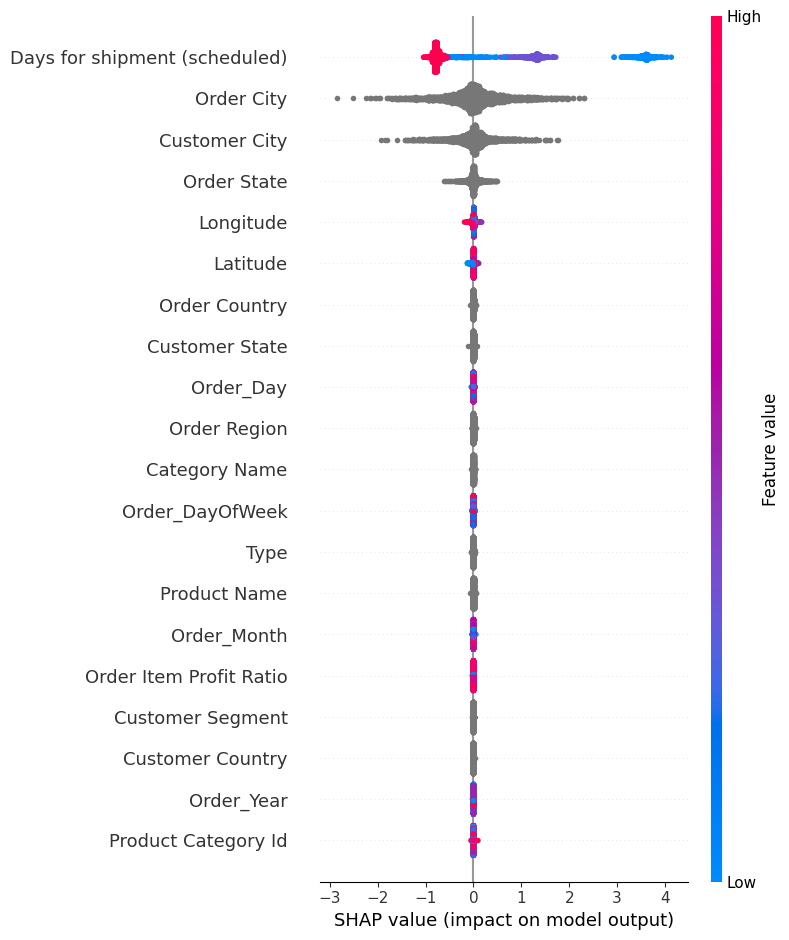

In [21]:
# ============================================================
# 19. OPTIONAL SHAP SUMMARY ON VALIDATION SAMPLE
# ============================================================

import shap

X_shap = X_val_final.sample(
    n=min(3000, len(X_val_final)),
    random_state=RANDOM_STATE,
)

explainer = shap.TreeExplainer(final_xgb)
shap_values = explainer.shap_values(X_shap)

shap.summary_plot(
    shap_values,
    X_shap,
    max_display=20,
    show=True,
)

## 20. Train LightGBM and CatBoost on the same locked feature set

All three ensemble components use identical rows and final features.

In [22]:
# ============================================================
# 20. LIGHTGBM FINAL COMPONENT
# ============================================================

final_lgb = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1,
)

final_lgb.fit(
    X_train_final,
    y_train,
    categorical_feature=categorical_cols,
)

lgb_train_prob = final_lgb.predict_proba(X_train_final)[:, 1]
lgb_val_prob = final_lgb.predict_proba(X_val_final)[:, 1]

print("LightGBM trained successfully.")

LightGBM trained successfully.


In [23]:
# ============================================================
# 21. CATBOOST FINAL COMPONENT
# ============================================================

final_cat = CatBoostClassifier(
    iterations=400,
    depth=8,
    learning_rate=0.08,
    loss_function="Logloss",
    eval_metric="F1",
    random_seed=RANDOM_STATE,
    verbose=False,
)

final_cat.fit(
    X_train_final,
    y_train,
    cat_features=categorical_cols,
)

cat_train_prob = final_cat.predict_proba(X_train_final)[:, 1]
cat_val_prob = final_cat.predict_proba(X_val_final)[:, 1]

print("CatBoost trained successfully.")

CatBoost trained successfully.


In [24]:
# ============================================================
# 22. VALIDATION MODEL COMPARISON
# ============================================================

model_val_probabilities = {
    "XGBoost": xgb_val_prob,
    "LightGBM": lgb_val_prob,
    "CatBoost": cat_val_prob,
}

comparison_rows = []
for model_name, prob in model_val_probabilities.items():
    m = metrics_from_prob(y_val, prob, threshold=0.50)
    m["Model"] = model_name
    comparison_rows.append(m)

validation_model_comparison = pd.DataFrame(comparison_rows)[
    ["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
]

display(validation_model_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost,0.6737,0.7434,0.6564,0.6972,0.7389
1,LightGBM,0.6620,0.7315,0.6468,0.6865,0.7298
2,CatBoost,0.6749,0.7653,0.6230,0.6869,0.7321


## 23. Three-model soft-voting ensemble and validation threshold selection

The ensemble uses a fixed equal-weight probability average. Its decision threshold is selected **only on validation**. The search begins at 0.10 so an optimum at the old 0.25 lower boundary is not accidentally truncated.
**Ensemble note:** this version intentionally uses equal-weight probability averaging as the reproducible baseline. Learned weights or stacking should only be evaluated on the validation set after this filtered pipeline has been run successfully end to end; the final test set must remain untouched for that tuning.


In [25]:
# ============================================================
# 23. THREE-MODEL ENSEMBLE — TRAIN + VALIDATION ONLY
# ============================================================

ensemble_train_prob = (
    xgb_train_prob + lgb_train_prob + cat_train_prob
) / 3.0

ensemble_val_prob = (
    xgb_val_prob + lgb_val_prob + cat_val_prob
) / 3.0

thresholds = np.arange(0.10, 0.76, 0.01)
threshold_rows = []

for threshold in thresholds:
    m = metrics_from_prob(y_val, ensemble_val_prob, threshold=threshold)
    m["Threshold"] = threshold
    threshold_rows.append(m)

threshold_results = pd.DataFrame(threshold_rows)
best_row = threshold_results.loc[threshold_results["F1"].idxmax()]
BEST_THRESHOLD = float(best_row["Threshold"])

print("SELECTED ENSEMBLE THRESHOLD")
print("=" * 55)
print(f"Threshold : {BEST_THRESHOLD:.2f}")
print(f"Accuracy  : {best_row['Accuracy']:.4f}")
print(f"Precision : {best_row['Precision']:.4f}")
print(f"Recall    : {best_row['Recall']:.4f}")
print(f"F1        : {best_row['F1']:.4f}")
print(f"ROC-AUC   : {best_row['ROC-AUC']:.4f}")

print("\nTop validation thresholds by F1:")
display(
    threshold_results.sort_values("F1", ascending=False)
                     .head(15)
                     .round(4)
)

SELECTED ENSEMBLE THRESHOLD
Threshold : 0.18
Accuracy  : 0.5783
Precision : 0.5764
Recall    : 0.9927
F1        : 0.7293
ROC-AUC   : 0.7402

Top validation thresholds by F1:


,Accuracy,Precision,Recall,F1,ROC-AUC,Threshold
8,0.5783,0.5764,0.9927,0.7293,0.7402,0.18
10,0.5805,0.5783,0.9860,0.7290,0.7402,0.20
9,0.5789,0.5770,0.9892,0.7289,0.7402,0.19
7,0.5765,0.5752,0.9944,0.7288,0.7402,0.17
12,0.5833,0.5806,0.9786,0.7288,0.7402,0.22
13,0.5856,0.5826,0.9729,0.7288,0.7402,0.23
11,0.5814,0.5792,0.9825,0.7287,0.7402,0.21
6,0.5751,0.5742,0.9960,0.7285,0.7402,0.16
14,0.5873,0.5842,0.9669,0.7284,0.7402,0.24
16,0.5926,0.5890,0.9537,0.7282,0.7402,0.26


In [26]:
# ============================================================
# 24. DEVELOPMENT PERFORMANCE — TRAIN VS VALIDATION
# ============================================================

ensemble_train_metrics = metrics_from_prob(
    y_train,
    ensemble_train_prob,
    threshold=BEST_THRESHOLD,
)
ensemble_val_metrics = metrics_from_prob(
    y_val,
    ensemble_val_prob,
    threshold=BEST_THRESHOLD,
)

dev_comparison = pd.DataFrame({
    "Metric": list(ensemble_train_metrics.keys()),
    "Train": list(ensemble_train_metrics.values()),
    "Validation": list(ensemble_val_metrics.values()),
})
dev_comparison["Gap"] = dev_comparison["Train"] - dev_comparison["Validation"]

display(dev_comparison.round(4))

,Metric,Train,Validation,Gap
0,Accuracy,0.7377,0.5783,0.1594
1,Precision,0.6866,0.5764,0.1102
2,Recall,1.0000,0.9927,0.0073
3,F1,0.8142,0.7293,0.0849
4,ROC-AUC,0.9930,0.7402,0.2527


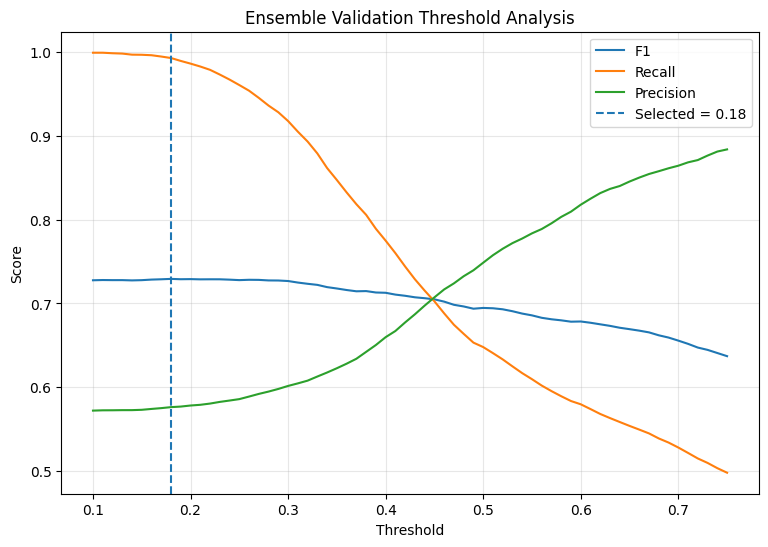

In [27]:
# ============================================================
# 25. VALIDATION THRESHOLD GRAPH
# ============================================================

plt.figure(figsize=(9, 6))
plt.plot(threshold_results["Threshold"], threshold_results["F1"], label="F1")
plt.plot(threshold_results["Threshold"], threshold_results["Recall"], label="Recall")
plt.plot(threshold_results["Threshold"], threshold_results["Precision"], label="Precision")
plt.axvline(
    BEST_THRESHOLD,
    linestyle="--",
    label=f"Selected = {BEST_THRESHOLD:.2f}",
)
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Ensemble Validation Threshold Analysis")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 26. FINAL TEST — unlock only now

At this point the feature representation, XGBoost tuning, ensemble members, ensemble weighting, and threshold are already fixed. The test set is now used for the final performance estimate.

In [28]:
# ============================================================
# 26. FINAL UNTOUCHED TEST EVALUATION
# ============================================================

# Test probabilities are deliberately generated only after the model is locked.
xgb_test_prob = final_xgb.predict_proba(X_test_final)[:, 1]
lgb_test_prob = final_lgb.predict_proba(X_test_final)[:, 1]
cat_test_prob = final_cat.predict_proba(X_test_final)[:, 1]

ensemble_test_prob = (
    xgb_test_prob + lgb_test_prob + cat_test_prob
) / 3.0

ensemble_test_pred = (
    ensemble_test_prob >= BEST_THRESHOLD
).astype(int)

final_accuracy = accuracy_score(y_test, ensemble_test_pred)
final_precision = precision_score(y_test, ensemble_test_pred, zero_division=0)
final_recall = recall_score(y_test, ensemble_test_pred, zero_division=0)
final_f1 = f1_score(y_test, ensemble_test_pred, zero_division=0)
final_roc_auc = roc_auc_score(y_test, ensemble_test_prob)

print("FINAL UNTOUCHED TEST RESULTS")
print("=" * 60)
print(f"Threshold : {BEST_THRESHOLD:.2f}")
print(f"Accuracy  : {final_accuracy:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1 Score  : {final_f1:.4f}")
print(f"ROC-AUC   : {final_roc_auc:.4f}")

final_cm = confusion_matrix(y_test, ensemble_test_pred)
print("\nConfusion Matrix:")
print(final_cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        ensemble_test_pred,
        target_names=["Not Late", "Late"],
        zero_division=0,
    )
)

FINAL UNTOUCHED TEST RESULTS
Threshold : 0.18
Accuracy  : 0.5690
Precision : 0.5684
Recall    : 0.9898
F1 Score  : 0.7222
ROC-AUC   : 0.7374

Confusion Matrix:
[[  233 11053]
 [  150 14559]]

Classification Report:
              precision    recall  f1-score   support

    Not Late       0.61      0.02      0.04     11286
        Late       0.57      0.99      0.72     14709

    accuracy                           0.57     25995
   macro avg       0.59      0.51      0.38     25995
weighted avg       0.59      0.57      0.43     25995



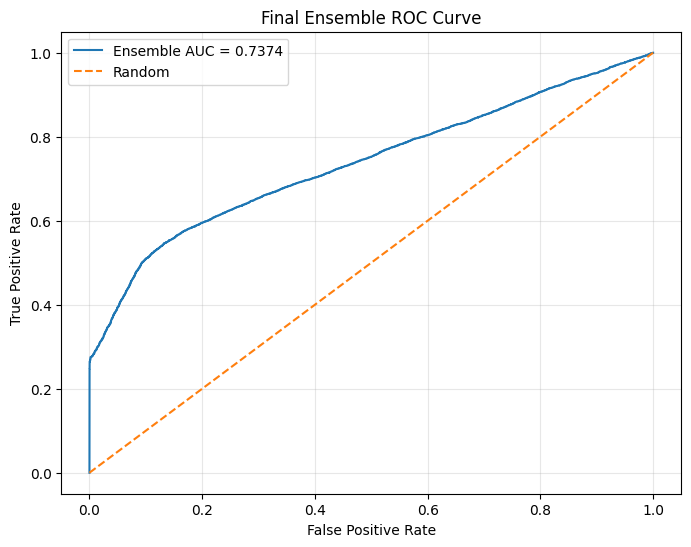

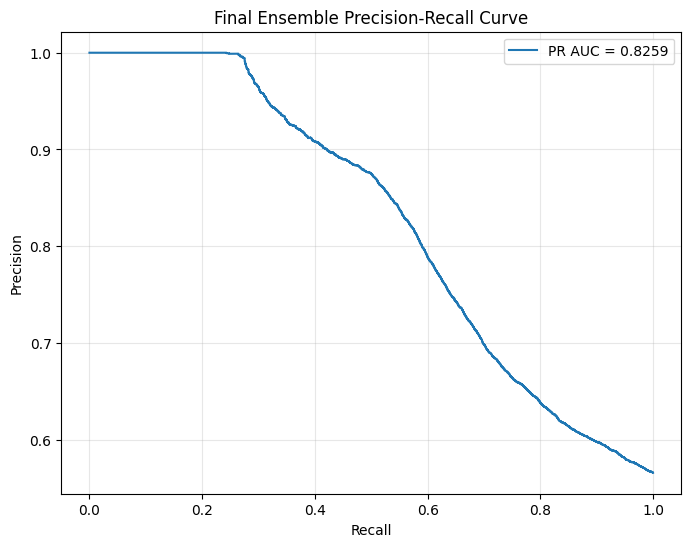

In [29]:
# ============================================================
# 27. FINAL ROC AND PRECISION-RECALL CURVES
# ============================================================

fpr, tpr, _ = roc_curve(y_test, ensemble_test_prob)
roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Ensemble AUC = {roc_auc_value:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final Ensemble ROC Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    ensemble_test_prob,
)
pr_auc_value = auc(recall_curve, precision_curve)

plt.figure(figsize=(8, 6))
plt.plot(recall_curve, precision_curve, label=f"PR AUC = {pr_auc_value:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Final Ensemble Precision-Recall Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [30]:
# ============================================================
# 28. FINAL PERFORMANCE SUMMARY
# ============================================================

final_model_comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    "Final 3-Model Ensemble": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_roc_auc,
    ],
})

display(final_model_comparison.round(4))

,Metric,Final 3-Model Ensemble
0,Accuracy,0.5690
1,Precision,0.5684
2,Recall,0.9898
3,F1,0.7222
4,ROC-AUC,0.7374


## 29. Save complete inference artifacts

In addition to the three models and threshold, this saves the exact feature order and categorical levels so deployment uses the same schema as training.

In [31]:
# ============================================================
# 29. SAVE FINAL ENSEMBLE ARTIFACTS
# ============================================================

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

final_features = list(X_train_final.columns)
category_levels = {
    col: X_train_final[col].cat.categories.tolist()
    for col in categorical_cols
}

joblib.dump(final_xgb, MODEL_DIR / "final_xgboost.pkl")
joblib.dump(final_lgb, MODEL_DIR / "final_lightgbm.pkl")
joblib.dump(final_cat, MODEL_DIR / "final_catboost.pkl")
joblib.dump(final_features, MODEL_DIR / "final_features.pkl")
joblib.dump(categorical_cols, MODEL_DIR / "final_categorical_features.pkl")
joblib.dump(category_levels, MODEL_DIR / "final_category_levels.pkl")
joblib.dump(BEST_THRESHOLD, MODEL_DIR / "final_threshold.pkl")
joblib.dump(preprocessor, MODEL_DIR / "baseline_preprocessor.pkl")

ensemble_config = {
    "models": ["XGBoost", "LightGBM", "CatBoost"],
    "ensemble_method": "equal_weight_probability_average",
    "weights": [1 / 3, 1 / 3, 1 / 3],
    "threshold": BEST_THRESHOLD,
    "target": TARGET,
    "split_method": "reconstructed_order_group_70_15_15",
    "threshold_selected_on": "validation",
    "test_used_for_model_selection": False,
    "shipping_representation": SHIPPING_REPRESENTATION,
    "dropped_columns": FINAL_DROP_COLUMNS,
    "order_status_available_at_prediction": ORDER_STATUS_AVAILABLE_AT_PREDICTION,
    "non_shipment_rows_filtered_before_split": True,
    "excluded_order_statuses": list(NON_SHIPMENT_STATUSES),
    "n_features": len(final_features),
    "n_categorical_features": len(categorical_cols),
    "unknown_category": UNKNOWN_CATEGORY,
    "order_group_columns": order_group_columns,
}

joblib.dump(
    ensemble_config,
    MODEL_DIR / "final_ensemble_config.pkl",
)

print("Artifacts saved to:", MODEL_DIR.resolve())
print("Saved threshold:", BEST_THRESHOLD)
print("Saved feature count:", len(final_features))

Artifacts saved to: /content/models
Saved threshold: 0.17999999999999997
Saved feature count: 32


In [32]:
# ============================================================
# 30. VERIFY SAVED ARTIFACTS
# ============================================================

loaded_xgb = joblib.load(MODEL_DIR / "final_xgboost.pkl")
loaded_lgb = joblib.load(MODEL_DIR / "final_lightgbm.pkl")
loaded_cat = joblib.load(MODEL_DIR / "final_catboost.pkl")
loaded_features = joblib.load(MODEL_DIR / "final_features.pkl")
loaded_categorical = joblib.load(MODEL_DIR / "final_categorical_features.pkl")
loaded_category_levels = joblib.load(MODEL_DIR / "final_category_levels.pkl")
loaded_threshold = joblib.load(MODEL_DIR / "final_threshold.pkl")
loaded_config = joblib.load(MODEL_DIR / "final_ensemble_config.pkl")

print("Loaded threshold:", loaded_threshold)
print("Config threshold:", loaded_config["threshold"])
print("Feature count:", len(loaded_features))

assert float(loaded_threshold) == float(loaded_config["threshold"])
assert loaded_features == final_features

print("Saved-artifact verification: PASS")

Loaded threshold: 0.17999999999999997
Config threshold: 0.17999999999999997
Feature count: 32
Saved-artifact verification: PASS


## 31. Reusable inference helper

This function enforces the saved feature order and categorical schema. Unknown categorical values are mapped to `__UNKNOWN__` rather than silently changing category codes.

In [33]:
# ============================================================
# 31. PREPARE NEW DATA FOR INFERENCE
# ============================================================

def prepare_inference_features(new_data: pd.DataFrame) -> pd.DataFrame:
    data = new_data.copy()

    # Remove fields intentionally excluded from the final feature set.
    for col in loaded_config["dropped_columns"]:
        if col in data.columns:
            data = data.drop(columns=[col])

    # Target/group helper must never be a model input.
    for forbidden in [TARGET, "_Order_Group_ID"]:
        if forbidden in data.columns:
            data = data.drop(columns=[forbidden])

    missing_features = [c for c in loaded_features if c not in data.columns]
    if missing_features:
        raise ValueError(f"Missing required features: {missing_features}")

    data = data[loaded_features].copy()

    for col in loaded_categorical:
        levels = loaded_category_levels[col]
        known_levels = set(levels)

        # Convert unknown values to the explicit unknown token.
        data[col] = data[col].astype("object")
        data[col] = data[col].where(
            data[col].isin(known_levels),
            UNKNOWN_CATEGORY,
        )
        data[col] = pd.Categorical(data[col], categories=levels)

    return data


def predict_supplyprescript(new_data: pd.DataFrame) -> pd.DataFrame:
    """
    Score delivery-delay risk only for orders that are eligible shipment cases.

    If Order Status is supplied and is CANCELED or SUSPECTED_FRAUD, the row is
    intentionally NOT scored because those outcomes were excluded from the
    model's training population.
    """
    result = pd.DataFrame(
        {
            "Late_Risk_Probability": np.nan,
            "Predicted_Late_Risk": pd.Series(
                pd.NA,
                index=new_data.index,
                dtype="Int64",
            ),
            "Prediction_Eligible": True,
            "Exclusion_Reason": pd.Series(
                pd.NA,
                index=new_data.index,
                dtype="string",
            ),
        },
        index=new_data.index,
    )

    eligible_mask = pd.Series(True, index=new_data.index)

    if "Order Status" in new_data.columns:
        status = (
            new_data["Order Status"]
            .astype("string")
            .str.strip()
            .str.upper()
        )

        excluded_mask = status.isin(
            loaded_config.get(
                "excluded_order_statuses",
                list(NON_SHIPMENT_STATUSES),
            )
        )

        eligible_mask &= ~excluded_mask

        result.loc[excluded_mask, "Prediction_Eligible"] = False
        result.loc[
            excluded_mask,
            "Exclusion_Reason",
        ] = "Non-shipment order status"

    if eligible_mask.any():
        eligible_data = new_data.loc[eligible_mask].copy()
        features = prepare_inference_features(eligible_data)

        p_xgb = loaded_xgb.predict_proba(features)[:, 1]
        p_lgb = loaded_lgb.predict_proba(features)[:, 1]
        p_cat = loaded_cat.predict_proba(features)[:, 1]

        probability = (p_xgb + p_lgb + p_cat) / 3.0
        prediction = (probability >= loaded_threshold).astype(int)

        result.loc[eligible_mask, "Late_Risk_Probability"] = probability
        result.loc[eligible_mask, "Predicted_Late_Risk"] = prediction

    return result


print("Inference helpers ready.")


Inference helpers ready.


In [34]:
# ============================================================
# 32. SAMPLE PREDICTIONS AFTER FINAL EVALUATION
# ============================================================

sample_indices = X_test.sample(n=min(5, len(X_test)), random_state=RANDOM_STATE).index
sample_raw = X.loc[sample_indices].copy()

sample_predictions = predict_supplyprescript(sample_raw)
sample_predictions["Actual_Late_Risk"] = y.loc[sample_indices]

display(sample_predictions)

,Late_Risk_Probability,Predicted_Late_Risk,Prediction_Eligible,Exclusion_Reason,Actual_Late_Risk
80660,0.287567,1,True,<NA>,0
177924,0.411570,1,True,<NA>,0
12327,0.913359,1,True,<NA>,1
12434,0.081028,0,True,<NA>,1
128815,0.268741,1,True,<NA>,0


In [35]:
# ============================================================
# 33. FINAL LEAKAGE + CONSISTENCY AUDIT
# ============================================================

final_audit = {
    "excluded_nonshipment_rows_remaining": int(
        df["Order Status"]
          .astype("string")
          .str.strip()
          .str.upper()
          .isin(NON_SHIPMENT_STATUSES)
          .sum()
    ),
    "target_in_features": TARGET in X_train_final.columns,
    "order_group_id_in_features": "_Order_Group_ID" in X_train_final.columns,
    "train_val_group_overlap": len(set(groups_train) & set(groups_val)),
    "train_test_group_overlap": len(set(groups_train) & set(groups_test)),
    "val_test_group_overlap": len(set(groups_val) & set(groups_test)),
    "train_test_row_overlap": len(set(X_train_final.index) & set(X_test_final.index)),
    "threshold_saved_matches_selected": float(loaded_threshold) == float(BEST_THRESHOLD),
    "all_models_same_feature_count": (
        X_train_final.shape[1] == len(loaded_features)
    ),
}

for key, value in final_audit.items():
    print(f"{key}: {value}")

assert final_audit["excluded_nonshipment_rows_remaining"] == 0
assert final_audit["target_in_features"] is False
assert final_audit["order_group_id_in_features"] is False
assert final_audit["train_val_group_overlap"] == 0
assert final_audit["train_test_group_overlap"] == 0
assert final_audit["val_test_group_overlap"] == 0
assert final_audit["train_test_row_overlap"] == 0
assert final_audit["threshold_saved_matches_selected"] is True

print("\nFINAL AUDIT: PASS")

excluded_nonshipment_rows_remaining: 0
target_in_features: False
order_group_id_in_features: False
train_val_group_overlap: 0
train_test_group_overlap: 0
val_test_group_overlap: 0
train_test_row_overlap: 0
threshold_saved_matches_selected: True
all_models_same_feature_count: True

FINAL AUDIT: PASS


# SupplyPrescript ML output for the prescriptive layer

The ML layer now produces a calibrated **late-delivery risk probability** and binary risk flag without using the final test set for model or threshold selection.

The next project layer should consume the probability as an input to the optimization/prescriptive engine, where candidate interventions can be evaluated under cost, capacity, SLA, inventory, and operational constraints.